In [ ]:
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")


In [3]:
!pip install groq
!pip install sentence-transformers
!pip install numpy
!pip install panda
!pip install matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for panda: filename=panda-0.3.1-py3-none-any.whl size=7239 sha256=8f93907fdcb2a23382e434be496d78b4f0351b4a4195d367841f0412dfaf77a9
  Stored in directory: /root/.cache/pip/wheels/98/41/5b/6ca54e0b6a35e1b7248c12f56fcb753dfb7717fefaa0fb45f5
Successfully built panda


In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

texto = "The quick brown fox jumps over the lazy dog"

embedding = model.encode(texto)

print(len(embedding))
print(embedding)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

384
[ 3.54968086e-02  6.12862706e-02  5.26920892e-02  7.07050636e-02
  3.31013985e-02 -3.06696165e-02  6.62059989e-03 -6.11832924e-02
 -1.32599624e-03  1.06456624e-02  3.86499502e-02  3.99532132e-02
 -3.83675583e-02 -1.66688133e-02 -5.61558455e-03 -2.43558772e-02
 -3.59968916e-02 -3.02429218e-02  5.84700257e-02 -4.94961590e-02
 -7.72954822e-02 -5.23877293e-02  2.45271642e-02  2.93105468e-02
 -7.39091635e-02 -2.49591749e-02 -6.53141961e-02 -4.28865291e-02
  7.11656436e-02 -1.13819428e-01 -1.26593439e-02  3.96260917e-02
 -2.10036337e-02  1.78063903e-02 -3.18874456e-02 -9.11229923e-02
  5.91224767e-02 -7.30397133e-03  3.31367664e-02  2.99061295e-02
  4.21688296e-02 -1.69129707e-02 -4.50015813e-02  2.96744630e-02
 -9.92584825e-02  5.32891750e-02 -7.64784738e-02 -1.48680210e-02
  1.52495010e-02  1.37893576e-02 -4.41923700e-02 -2.78392974e-02
  6.73083123e-03  5.64969815e-02  7.21781552e-02 -4.12063720e-03
 -3.77657544e-03 -3.55087742e-02  4.90684211e-02 -1.03429854e-02
  2.36084051e-02  3.6

In [1]:
import numpy as np
def distancia_euclidiana(embedding_a, embedding_b) -> float:
  p1 = np.array(embedding_a)
  p2 = np.array(embedding_b)
  distancia = np.linalg.norm(p1 - p2)

  return float(distancia)

embedding_a = [1, 0, 0]
embedding_b = [0, 1, 0]
embedding_c = [1, 0, 0]

print(distancia_euclidiana(embedding_a, embedding_b))
print(distancia_euclidiana(embedding_a, embedding_c))
print(distancia_euclidiana(embedding_b, embedding_c))

#comparar item por item
#salvar os embedding em um arquivo e depois importar para comparar com as resposta da query

1.4142135623730951
0.0
1.4142135623730951


In [2]:
import numpy as np
def similaridade_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
  norm_v1 = np.linalg.norm(vec1)
  norm_v2 = np.linalg.norm(vec2)
  if norm_v1 == 0 or norm_v2 == 0:
      return 0.0
  return float(np.dot(vec1, vec2) / (norm_v1 * norm_v2))


def distancia_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:

  #similaridade
  cos_sim = similaridade_cosseno(vec1, vec2)
  #distancia do coseno
  cos_dist = 1.0 - cos_sim
  return float(cos_dist)

embedding_a = [1, 0, 0]
embedding_b = [0, 1, 0]
embedding_c = [1, 0, 0]

print(distancia_cosseno(embedding_a, embedding_b))
print(distancia_cosseno(embedding_a, embedding_c))
print(distancia_cosseno(embedding_b, embedding_c))


1.0
0.0
1.0


In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

def get_embeddings(textos):
  embedding_textos = model.encode(textos)
  return embedding_textos


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[[-0.10839419  0.07542188 -0.08832744 ... -0.01920225 -0.02041903
   0.0466912 ]
 [-0.02637674  0.0623263  -0.10856692 ...  0.04402547  0.04956052
  -0.12355088]
 [-0.07402309  0.03264865 -0.03444745 ...  0.0473307   0.05951273
  -0.06910143]
 ...
 [-0.05431159  0.01404568 -0.02481632 ... -0.02175924 -0.01688574
   0.01678814]
 [-0.04803829 -0.00180394 -0.01392179 ... -0.07219616 -0.00880814
   0.06121145]
 [ 0.00128552  0.06218153 -0.12708868 ... -0.04002746 -0.01539149
   0.04839014]]
              gato        felino  cachorro     carro  caminhão      moto  \
gato      0.000000  7.222936e-01  0.680787  0.653900  0.676041  0.426597   
felino    0.722294 -1.192093e-07  0.620524  0.615740  0.816916  0.772582   
cachorro  0.680787  6.205238e-01  0.000000  0.593457  0.634773  0.753358   
carro     0.653900  6.157404e-01  0.593457  0.000000  0.510586  0.656618   
caminhão  0.676041  8.169157e-01  0.634773  0.510586  0.000000  0.766498   
moto      0.426597  7.725818e-01  0.753358  0.656618

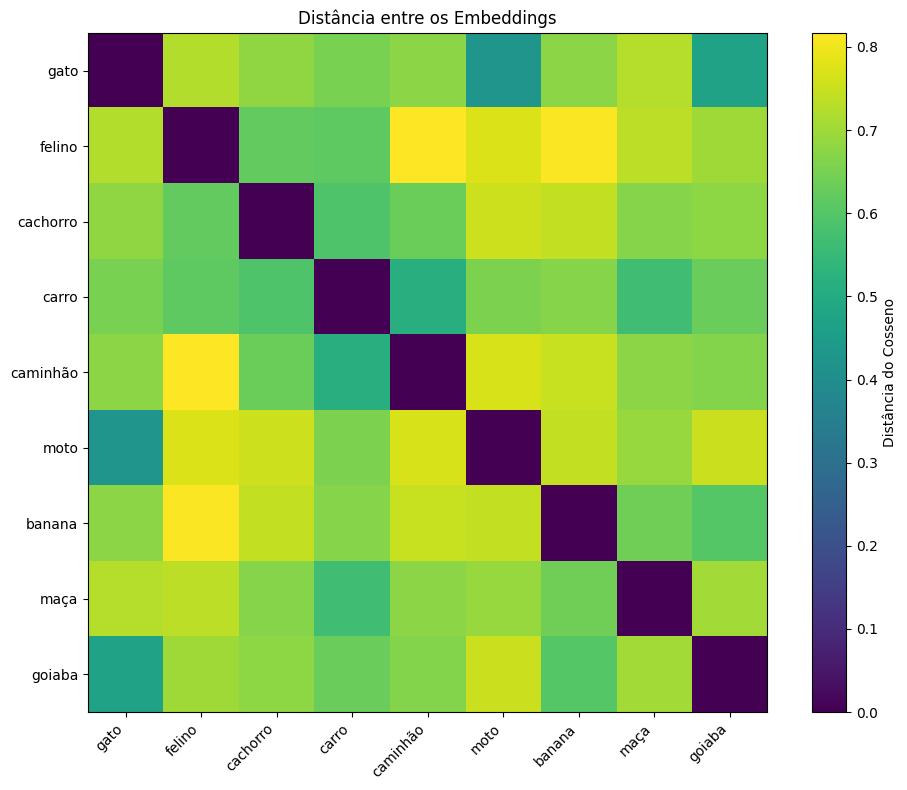

In [6]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

textos = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "maça", "goiaba"]

embedding_textos = model.encode(textos)

n = len(embedding_textos)
print("=========")
print(embedding_textos)
matriz_distancias = np.zeros((n,n))

for i in range(n):
  for j in range(n):
    matriz_distancias [i][j] = distancia_cosseno(
        embedding_textos[i],
        embedding_textos[j]
    )

df = pd.DataFrame(
    matriz_distancias,
    index=textos,
    columns=textos
)

print(df)

plt.figure(figsize=(10, 8))

plt.imshow(
    df,
    interpolation="nearest"
)

plt.xticks(
    range(len(textos)),
    textos,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(textos)),
    textos
)

plt.colorbar(
    label="Distância do Cosseno"
)

plt.title("Distância entre os Embeddings")

plt.tight_layout()

#plt.show()




In [ ]:
import numpy as np
import pandas as pd

frase_ancora = "O cachorro correu no parque e brincou com a bola."

frases_comparacao = [
    ("Similar (mesmo sentido, palavras diferentes)", "Um cão estava correndo no jardim e brincando com seu brinquedo."),
    ("Relacionado (mesmo contexto de animais)", "O gato dormiu na almofada da sala durante toda a tarde."),
    ("Diferente (outro domínio - economia)", "A taxa de juros do banco central subiu dois pontos percentuais."),
    ("Oposto/Negação", "Nenhum animal esteve no parque e o cão permaneceu preso em casa.")
]

vec_ancora =  np.array(get_embeddings(frase_ancora), dtype=np.float32)

vec_comparacao = []

for categoria, frase in frases_comparacao:
  vec = get_embeddings(frase)
  vec_comparacao.append(np.array(vec, dtype=np.float32))

resultados = []
for (categoria, texto), vec in zip(frases_comparacao, vec_comparacao):
    resultados.append({
          "Texto": texto,
          "Dist. Euclidiana": round(distancia_euclidiana(vec_ancora, vec), 4),
          "Similaridade Cosseno": round(similaridade_cosseno(vec_ancora, vec), 4),
          "Distância Cosseno": round(distancia_cosseno(vec_ancora, vec), 4)})

df_resultados = pd.DataFrame(resultados)
print(df_resultados)


                                               Texto  Dist. Euclidiana  \
0  Um cão estava correndo no jardim e brincando c...            0.7602   
1  O gato dormiu na almofada da sala durante toda...            1.0110   
2  A taxa de juros do banco central subiu dois po...            1.0831   
3  Nenhum animal esteve no parque e o cão permane...            0.9634   

   Similaridade Cosseno  Distância Cosseno  
0                0.7111             0.2889  
1                0.4889             0.5111  
2                0.4135             0.5865  
3                0.5359             0.4641  
